# 2. Filtering Methods & Benchmarking
In this notebook, we apply our scratch-implemented filters to the noisy signals and compare their performance using RMSE (Root Mean Square Error) and SNR (Signal-to-Noise Ratio).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sys
import os
sys.path.append(os.path.abspath('..'))
from src.noise_generation import *
from src.filters import *
from src.evaluation import *

%matplotlib inline
plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# 1. Setup Signal and Noise
t, clean_signal = generate_clean_signal()
noisy_signals = {
    'Gaussian': add_gaussian_noise(clean_signal, std=1.0),
    'Spike': add_spike_noise(clean_signal, num_spikes=30, spike_amplitude=8),
    'Drift': add_drift_noise(clean_signal, drift_type='random_walk', drift_strength=0.1),
    'Seasonal': add_seasonal_noise(t, clean_signal, freq=0.5, amplitude=2.0),
    'Missing Data': add_missing_data(clean_signal, missing_pct=0.1, block_size=1)
}

In [3]:
# 2. Apply Filters and Evaluate
results = []
clean_outputs = {}

for noise_name, noisy_sig in noisy_signals.items():
    clean_outputs[noise_name] = {}
    
    # Standard Moving Average
    ma_clean = moving_average(noisy_sig, window_size=15)
    # Median Filter
    med_clean = median_filter(noisy_sig, window_size=15)
    # STL-like Classical Decomposition (extract trend as cleaned)
    stl_clean, _, _ = classical_decomposition(noisy_sig, period=20)
    # Kalman Filter
    kalman_clean = kalman_filter_1d(noisy_sig, process_variance=1e-2, measurement_variance=2.0)
    # Fourier LPF
    fourier_clean = fourier_low_pass_filter(noisy_sig, sample_rate=100, cutoff_freq=10)
    # Interpolation only
    interp_clean = linear_interpolate_missing(noisy_sig)
    
    filters = {
        'Moving Average': ma_clean,
        'Median Filter': med_clean,
        'STL Trend': stl_clean,
        'Kalman': kalman_clean,
        'Fourier LPF': fourier_clean,
        'Linear Interp': interp_clean
    }
    
    for filter_name, cleaned in filters.items():
        if len(cleaned) < len(clean_signal):
            pad_width = len(clean_signal) - len(cleaned)
            cleaned = np.pad(cleaned, (pad_width//2, pad_width - pad_width//2), mode='edge')
        
        clean_outputs[noise_name][filter_name] = cleaned
        rmse = calculate_rmse(clean_signal, cleaned)
        snr = calculate_snr(clean_signal, cleaned)
        results.append({'Noise Type': noise_name, 'Filter': filter_name, 'RMSE': rmse, 'SNR': snr})

df_results = pd.DataFrame(results)

In [4]:
# 3. Visualize Benchmarks (RMSE - Lower is Better)
pivot_rmse = df_results.pivot(index='Noise Type', columns='Filter', values='RMSE')
display(pivot_rmse.style.background_gradient(cmap='YlOrRd', axis=1))

print("\n--- SNR (Higher is Better) ---")
pivot_snr = df_results.pivot(index='Noise Type', columns='Filter', values='SNR')
display(pivot_snr.style.background_gradient(cmap='Greens', axis=1))

Filter,Fourier LPF,Kalman,Linear Interp,Median Filter,Moving Average,STL Trend
Noise Type,,,,,,
Drift,2.605478,2.596140,2.607144,2.608432,2.612518,2.624250
Gaussian,0.445251,0.641344,1.024032,0.423806,0.376500,0.447184
Missing Data,0.006839,0.609098,0.006385,0.181895,0.244543,0.383550
Seasonal,1.413517,1.423399,1.413506,1.412779,1.422615,1.437667
Spike,0.640035,0.677384,1.385641,0.189668,0.439155,0.479502



--- SNR (Higher is Better) ---


Filter,Fourier LPF,Kalman,Linear Interp,Median Filter,Moving Average,STL Trend
Noise Type,,,,,,
Drift,-4.130801,-4.099613,-4.136351,-4.140642,-4.154237,-4.193155
Gaussian,11.214851,8.045128,3.980677,11.643606,12.671649,11.177223
Missing Data,47.487023,8.493200,48.083376,18.770758,16.200082,11.579906
Seasonal,1.180925,1.120417,1.180993,1.185461,1.125199,1.033782
Spike,8.062867,7.570249,1.353936,18.627082,11.334599,10.571145


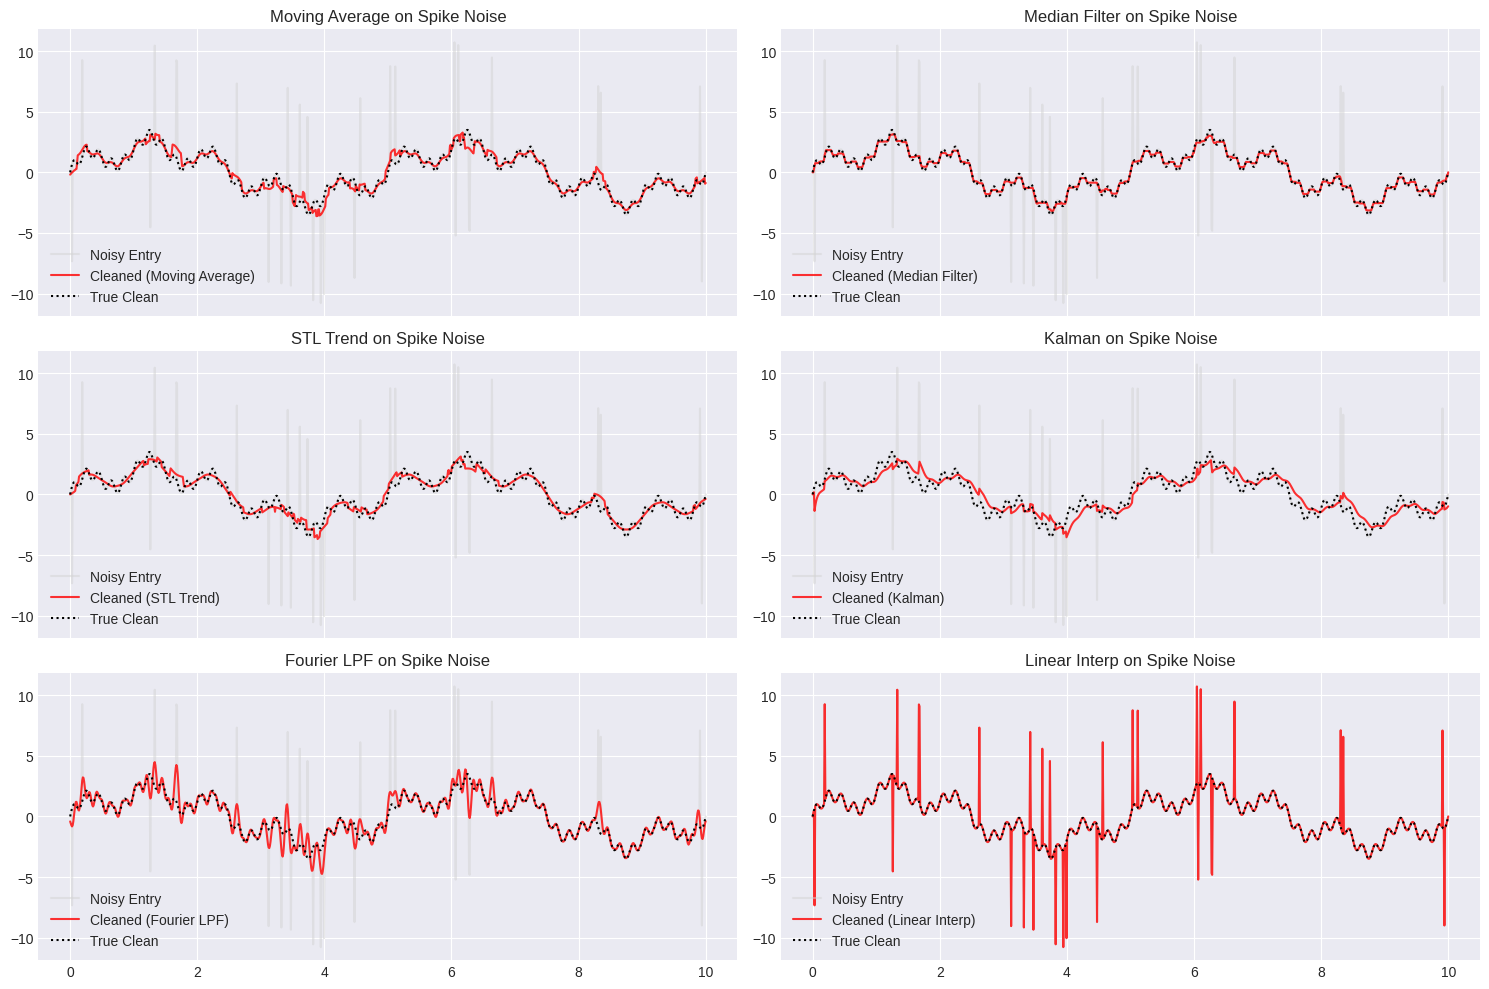

In [5]:
# 4. Plot Qualitative Comparisons for a specific noise
noise_to_plot = 'Spike'
fig, axs = plt.subplots(3, 2, figsize=(15, 10), sharex=True)
axs = axs.flatten()

for idx, (filter_name, cleaned) in enumerate(clean_outputs[noise_to_plot].items()):
    axs[idx].plot(t, noisy_signals[noise_to_plot], label='Noisy Entry', color='lightgray', alpha=0.5)
    axs[idx].plot(t, cleaned, label=f'Cleaned ({filter_name})', color='red', alpha=0.8)
    axs[idx].plot(t, clean_signal, label='True Clean', color='black', linestyle=':')
    axs[idx].set_title(f"{filter_name} on {noise_to_plot} Noise")
    axs[idx].legend()
    
plt.tight_layout()
plt.show()